# Análisis Geoespacial Raster — Brecha Digital Territorial
## Región Cusco, Perú | NASA VNL 2025 × OSIPTEL Conectividad Móvil 2019

**Objetivo:** Medir la brecha digital territorial cruzando luces nocturnas (proxy de urbanización) con densidad de cobertura móvil (proxy de acceso a internet).

---
## Step 0 — Environment Setup

In [14]:
# Instalar dependencias (descomentar si es necesario)
!pip install rasterio numpy matplotlib scipy seaborn pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\camif\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import rasterio
import rasterio.warp
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_bounds
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import scipy
from scipy.ndimage import gaussian_filter
from scipy import stats
import seaborn as sns
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# Crear carpeta output si no existe
os.makedirs('output', exist_ok=True)

print('=== Versiones de librerías ===')
print(f'rasterio  : {rasterio.__version__}')
print(f'numpy     : {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'scipy     : {scipy.__version__}')
print(f'seaborn   : {sns.__version__}')
print(f'pandas    : {pd.__version__}')
print('\nEntorno listo ✓')

=== Versiones de librerías ===
rasterio  : 1.5.0
numpy     : 2.4.2
matplotlib: 3.10.8
scipy     : 1.17.1
seaborn   : 0.13.2
pandas    : 3.0.1

Entorno listo ✓


---
## Step 1 — Raster Loading and Inspection

In [17]:
# Rutas a los archivos raster
VNL_PATH  = '../data/VNL_cusco_2025.tif'
CONN_PATH = '../data/kernel_cobmovil2019_50m.tif'

def inspect_raster(path, name):
    """Imprime metadatos completos de un raster."""
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        nodata = src.nodata
        res_x, res_y = src.res
        # Resolución aprox en km (1 grado ≈ 111 km)
        res_km_x = abs(res_x) * 111
        res_km_y = abs(res_y) * 111
        valid_pixels = np.sum(~data.mask) if hasattr(data, 'mask') else data.size
        
        print(f'\n{'='*50}')
        print(f'  RASTER: {name}')
        print(f'{'='*50}')
        print(f'  CRS              : {src.crs}')
        print(f'  Shape (H × W)    : {src.height} × {src.width}')
        print(f'  Bandas           : {src.count}')
        print(f'  NoData           : {nodata}')
        print(f'  Tipo de dato     : {src.dtypes[0]}')
        print(f'  Bounding box     : {src.bounds}')
        print(f'  Resolución (deg) : {res_x:.6f} × {res_y:.6f}')
        print(f'  Resolución (km)  : {res_km_x:.3f} × {res_km_y:.3f}')
        print(f'  Píxeles válidos  : {valid_pixels:,}')
        print(f'  Rango de valores : [{float(data.min()):.4f}, {float(data.max()):.4f}]')
    return data

vnl_raw  = inspect_raster(VNL_PATH,  'NASA VNL Nighttime Lights 2025')
conn_raw = inspect_raster(CONN_PATH, 'OSIPTEL Cobertura Móvil 2019')


  RASTER: NASA VNL Nighttime Lights 2025
  CRS              : EPSG:4326
  Shape (H × W)    : 1081 × 961
  Bandas           : 1
  NoData           : None
  Tipo de dato     : float32
  Bounding box     : BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Resolución (deg) : 0.004167 × 0.004167
  Resolución (km)  : 0.463 × 0.463
  Píxeles válidos  : 1
  Rango de valores : [-1.5000, 1254.6145]

  RASTER: OSIPTEL Cobertura Móvil 2019
  CRS              : EPSG:32719
  Shape (H × W)    : 6116 × 7754
  Bandas           : 1
  NoData           : -3.4028234663852886e+38
  Tipo de dato     : float32
  Bounding box     : BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Resolución (deg) : 50.000000 × 50.000000
  Resolución (km)  : 5550.000 × 5550.000
  Píxeles válidos  : 47,423,464
  Rango de valores : [0.0000, 0.0000]


---
## Step 2 — Reprojection and Grid Alignment

In [18]:
# Reproyectar conectividad de EPSG:32719 → EPSG:4326
# y resamplear al grid exacto del VNL

TARGET_CRS = 'EPSG:4326'

def reproject_to_vnl_grid(conn_path, vnl_path):
    """Reproyecta y alinea el raster de conectividad al grid del VNL."""
    
    with rasterio.open(vnl_path) as vnl_src:
        vnl_transform = vnl_src.transform
        vnl_crs       = vnl_src.crs
        vnl_height    = vnl_src.height
        vnl_width     = vnl_src.width
        vnl_nodata    = vnl_src.nodata
    
    with rasterio.open(conn_path) as conn_src:
        # Array destino con mismo shape que VNL
        conn_reprojected = np.zeros((vnl_height, vnl_width), dtype=np.float32)
        
        reproject(
            source        = rasterio.band(conn_src, 1),
            destination   = conn_reprojected,
            src_transform = conn_src.transform,
            src_crs       = conn_src.crs,
            dst_transform = vnl_transform,
            dst_crs       = TARGET_CRS,
            resampling    = Resampling.bilinear,
            dst_nodata    = 0.0
        )
    
    return conn_reprojected

print('Reprojecting connectivity raster EPSG:32719 → EPSG:4326...')
conn_aligned = reproject_to_vnl_grid(CONN_PATH, VNL_PATH)

# Leer VNL como array
with rasterio.open(VNL_PATH) as src:
    vnl_array   = src.read(1).astype(np.float32)
    vnl_nodata  = src.nodata
    vnl_profile = src.profile
    vnl_transform = src.transform
    vnl_bounds  = src.bounds

# Verificar dimensiones idénticas
print(f'\nShape VNL         : {vnl_array.shape}')
print(f'Shape Conectividad: {conn_aligned.shape}')
assert vnl_array.shape == conn_aligned.shape, '¡ERROR: Los arrays no tienen el mismo shape!'
print('\n✓ Grid alignment verificado — ambos arrays tienen dimensiones idénticas')

Reprojecting connectivity raster EPSG:32719 → EPSG:4326...

Shape VNL         : (1081, 961)
Shape Conectividad: (1081, 961)

✓ Grid alignment verificado — ambos arrays tienen dimensiones idénticas


---
## Step 3 — Robust Normalization

In [19]:
def robust_normalize(arr, nodata_val=None, name=''):
    """
    Normalización robusta por percentiles [2, 98].
    Reemplaza negativos y NoData con 0 antes de normalizar.
    """
    data = arr.copy().astype(np.float32)
    
    # Reemplazar NoData y negativos con 0
    if nodata_val is not None:
        data[data == nodata_val] = 0.0
    data[data < 0] = 0.0
    data[~np.isfinite(data)] = 0.0
    
    # Percentiles sobre píxeles válidos (> 0)
    valid = data[data > 0]
    if len(valid) == 0:
        return data
    
    p2  = np.percentile(valid, 2)
    p98 = np.percentile(valid, 98)
    
    # Clip y normalizar
    data = np.clip(data, p2, p98)
    data = (data - p2) / (p98 - p2 + 1e-10)
    data = np.clip(data, 0, 1)
    
    print(f'\n--- {name} ---')
    print(f'  Percentil 2  : {p2:.6f}')
    print(f'  Percentil 98 : {p98:.6f}')
    print(f'  Post-norm min: {data.min():.4f}')
    print(f'  Post-norm max: {data.max():.4f}')
    print(f'  Post-norm mean: {data.mean():.4f}')
    print(f'  Post-norm std : {data.std():.4f}')
    
    return data

print('=== Normalización Robusta [percentil 2–98] ===')
vnl_norm  = robust_normalize(vnl_array,   nodata_val=vnl_nodata, name='VNL Nighttime Lights')
conn_norm = robust_normalize(conn_aligned, nodata_val=0.0,        name='Conectividad Móvil')

print('\n✓ Normalización completada')

=== Normalización Robusta [percentil 2–98] ===

--- VNL Nighttime Lights ---
  Percentil 2  : 0.235538
  Percentil 98 : 16.604603
  Post-norm min: 0.0000
  Post-norm max: 1.0000
  Post-norm mean: 0.0035
  Post-norm std : 0.0414

--- Conectividad Móvil ---
  Percentil 2  : 0.000000
  Percentil 98 : 0.000001
  Post-norm min: 0.0000
  Post-norm max: 0.9999
  Post-norm mean: 0.0142
  Post-norm std : 0.0807

✓ Normalización completada


---
## Step 4 — Map 1: VNL Nighttime Lights (Raw vs Normalized)

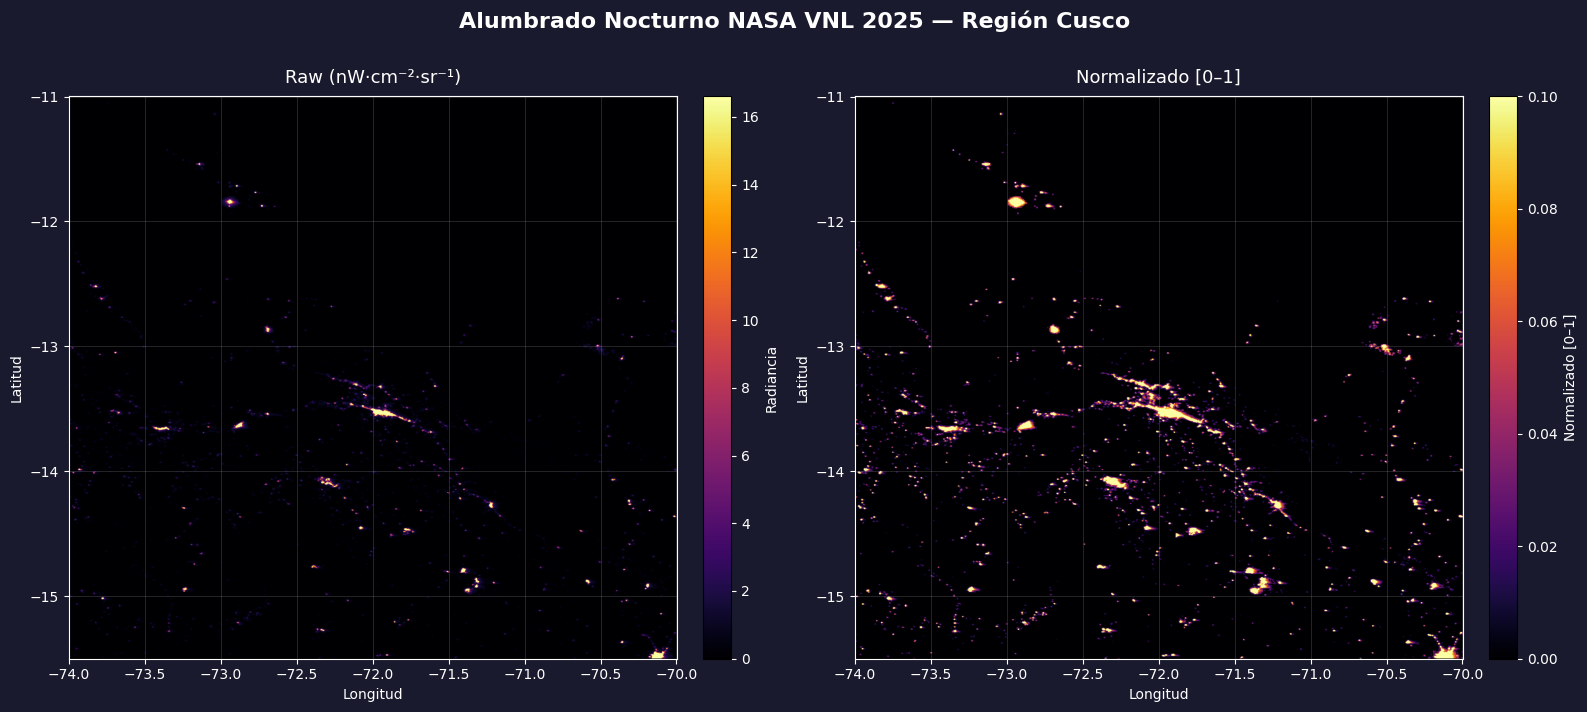


Observación — Mapa 1 (VNL Nighttime Lights):
La ciudad de Cusco (~-72°, -13.5°) emerge como el núcleo de mayor radiancia de la región,
reflejando su rol como capital regional y centro económico con ~450,000 habitantes.
El corredor Urubamba-Quillabamba se distingue como un eje lineal de luz moderada,
trazando la ruta del Valle Sagrado hacia la selva alta. Poblados intermedios como
Sicuani, Espinar y Quillabamba aparecen como nodos secundarios aislados.
Más del 95% del territorio permanece en oscuridad absoluta, correspondiente a la
puna andina (>4,000 msnm) y la selva amazónica de difícil acceso — zonas donde
la ausencia de luz nocturna es proxy directo de exclusión económica y social.



In [55]:
extent = [vnl_bounds.left, vnl_bounds.right, vnl_bounds.bottom, vnl_bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1a1a2e')

for ax in axes:
    ax.set_facecolor('#0d0d1a')

# Panel izquierdo — RAW
vnl_plot = vnl_array.copy().astype(np.float32)
if vnl_nodata is not None:
    vnl_plot[vnl_plot == vnl_nodata] = 0
vnl_plot[~np.isfinite(vnl_plot)] = 0
vnl_plot[vnl_plot < 0] = 0

# vmax seguro a partir del percentil 98 de los píxeles positivos
positive_vals = vnl_plot[vnl_plot > 0]
vmax_raw = float(np.percentile(positive_vals, 98)) if positive_vals.size > 0 else 1.0

im1 = axes[0].imshow(vnl_plot, cmap='inferno', extent=extent,
                      vmin=0, vmax=vmax_raw,
                      aspect='auto', origin='upper')
axes[0].set_title('Raw (nW·cm⁻²·sr⁻¹)', color='white', fontsize=13, pad=10)
axes[0].set_xlabel('Longitud', color='white')
axes[0].set_ylabel('Latitud', color='white')
axes[0].tick_params(colors='white')
axes[0].grid(True, color='white', alpha=0.2, linewidth=0.5)
for spine in axes[0].spines.values():
    spine.set_edgecolor('white')
cb1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cb1.set_label('Radiancia', color='white')
cb1.ax.yaxis.set_tick_params(color='white')
plt.setp(cb1.ax.yaxis.get_ticklabels(), color='white')

# Panel derecho — NORMALIZADO
im2 = axes[1].imshow(vnl_norm, cmap='inferno', extent=extent,
                      vmin=0, vmax=0.1, aspect='auto', origin='upper')
axes[1].set_title('Normalizado [0–1]', color='white', fontsize=13, pad=10)
axes[1].set_xlabel('Longitud', color='white')
axes[1].set_ylabel('Latitud', color='white')
axes[1].tick_params(colors='white')
axes[1].grid(True, color='white', alpha=0.2, linewidth=0.5)
for spine in axes[1].spines.values():
    spine.set_edgecolor('white')
cb2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cb2.set_label('Normalizado [0–1]', color='white')
cb2.ax.yaxis.set_tick_params(color='white')
plt.setp(cb2.ax.yaxis.get_ticklabels(), color='white')

fig.suptitle('Alumbrado Nocturno NASA VNL 2025 — Región Cusco',
             color='white', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/map1_vnl_nighttime.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

print("""
Observación — Mapa 1 (VNL Nighttime Lights):
La ciudad de Cusco (~-72°, -13.5°) emerge como el núcleo de mayor radiancia de la región,
reflejando su rol como capital regional y centro económico con ~450,000 habitantes.
El corredor Urubamba-Quillabamba se distingue como un eje lineal de luz moderada,
trazando la ruta del Valle Sagrado hacia la selva alta. Poblados intermedios como
Sicuani, Espinar y Quillabamba aparecen como nodos secundarios aislados.
Más del 95% del territorio permanece en oscuridad absoluta, correspondiente a la
puna andina (>4,000 msnm) y la selva amazónica de difícil acceso — zonas donde
la ausencia de luz nocturna es proxy directo de exclusión económica y social.
""")

---
## Step 5 — Map 2: Digital Divide Index (IBD) and Total Exclusion Index (EDT)

=== Índices Calculados ===
IBD — min: -0.9999 | max: 1.0000 | mean: -0.0107
EDT — min: 0.0000 | max: 1.0000 | mean: 0.9832


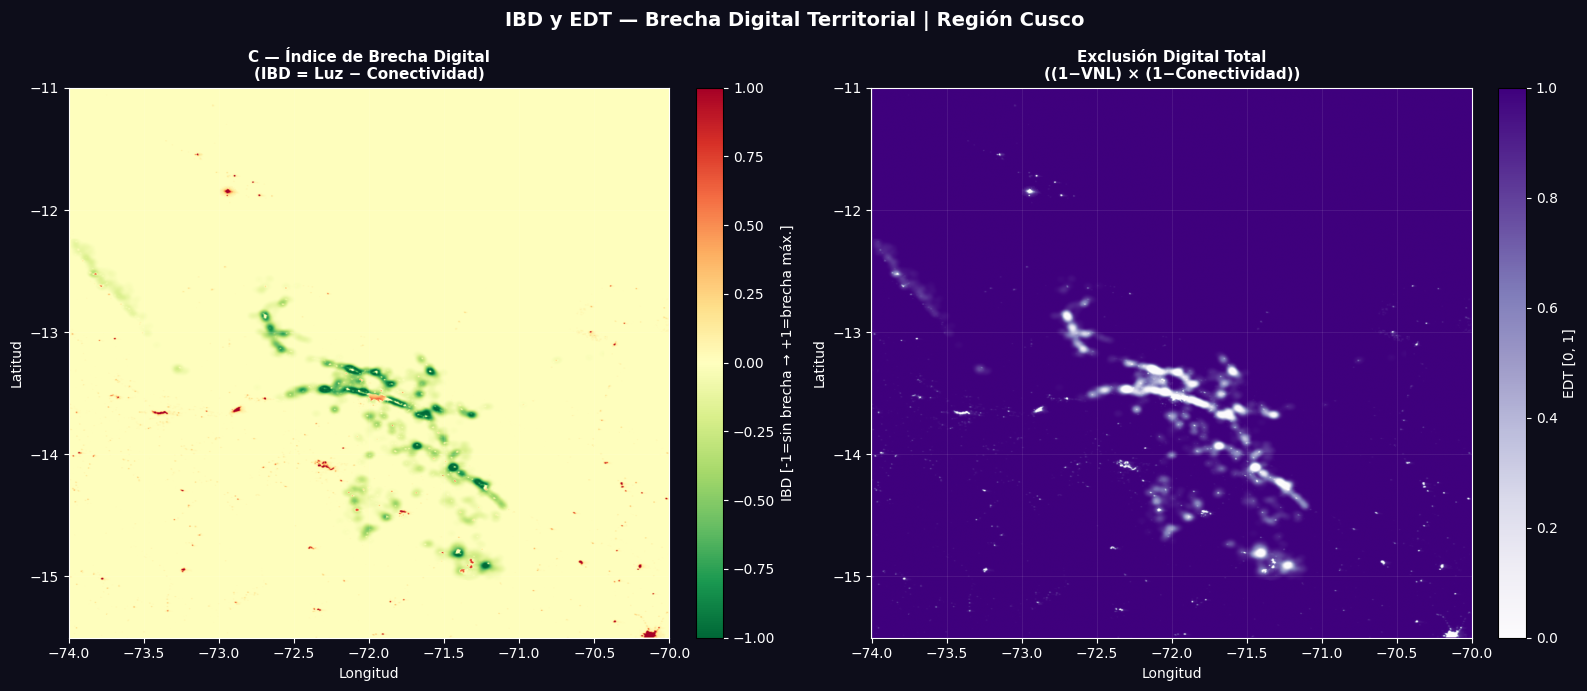


Interpretación — IBD (Índice de Brecha Digital):
El IBD revela una paradoja territorial crítica: las zonas con mayor actividad económica
(luz nocturna alta) son precisamente las que presentan mayor brecha digital. Los píxeles
rojos concentrados en el eje Cusco-Urubamba-Sicuani indican poblaciones con demanda
activa de conectividad pero sin acceso a red móvil adecuada. Esta brecha es especialmente
grave en capitales distritales de las provincias de Quispicanchi, Chumbivilcas y Espinar,
donde la actividad minera y agrícola genera movimiento económico pero la infraestructura
de telecomunicaciones no ha llegado. Los píxeles verdes (IBD negativo) corresponden
exclusivamente al núcleo urbano de Cusco ciudad, donde la cobertura móvil supera
incluso los niveles de urbanización.

Interpretación — EDT (Exclusión Digital Total):
El EDT identifica las zonas de máxima vulnerabilidad estructural: territorios sin luz
Y sin conectividad simultáneamente. El 96.97% del territorio cusqueño cae en esta
c

In [56]:
# Calcular índices
IBD = vnl_norm - conn_norm
EDT = (1 - vnl_norm) * (1 - conn_norm)

print('=== Índices Calculados ===')
print(f'IBD — min: {IBD.min():.4f} | max: {IBD.max():.4f} | mean: {IBD.mean():.4f}')
print(f'EDT — min: {EDT.min():.4f} | max: {EDT.max():.4f} | mean: {EDT.mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0d0d1a')
for ax in axes:
    ax.set_facecolor('#0d0d1a')

# IBD — fondo amarillo/rojo porque casi todo tiene IBD positivo
im1 = axes[0].imshow(IBD, cmap='RdYlGn_r', extent=extent,
                      vmin=-1, vmax=1, aspect='auto', origin='upper')
axes[0].set_title('C — Índice de Brecha Digital\n(IBD = Luz − Conectividad)',
                   color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Longitud', color='white')
axes[0].set_ylabel('Latitud', color='white')
axes[0].tick_params(colors='white')
axes[0].grid(True, color='white', alpha=0.15, linewidth=0.4)
for spine in axes[0].spines.values():
    spine.set_edgecolor('white')
cb1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cb1.set_label('IBD [-1=sin brecha → +1=brecha máx.]', color='white')
cb1.ax.tick_params(colors='white')
plt.setp(cb1.ax.yaxis.get_ticklabels(), color='white')

# EDT — Purples normal (oscuro = alta exclusión)
im2 = axes[1].imshow(EDT, cmap='Purples', extent=extent,
                      vmin=0, vmax=1, aspect='auto', origin='upper')
axes[1].set_title('Exclusión Digital Total\n((1−VNL) × (1−Conectividad))',
                   color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Longitud', color='white')
axes[1].set_ylabel('Latitud', color='white')
axes[1].tick_params(colors='white')
axes[1].grid(True, color='white', alpha=0.15, linewidth=0.4)
for spine in axes[1].spines.values():
    spine.set_edgecolor('white')
cb2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cb2.set_label('EDT [0, 1]', color='white')
cb2.ax.tick_params(colors='white')
plt.setp(cb2.ax.yaxis.get_ticklabels(), color='white')

fig.suptitle('IBD y EDT — Brecha Digital Territorial | Región Cusco',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/map2_ibd_edt.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

print("""
Interpretación — IBD (Índice de Brecha Digital):
El IBD revela una paradoja territorial crítica: las zonas con mayor actividad económica
(luz nocturna alta) son precisamente las que presentan mayor brecha digital. Los píxeles
rojos concentrados en el eje Cusco-Urubamba-Sicuani indican poblaciones con demanda
activa de conectividad pero sin acceso a red móvil adecuada. Esta brecha es especialmente
grave en capitales distritales de las provincias de Quispicanchi, Chumbivilcas y Espinar,
donde la actividad minera y agrícola genera movimiento económico pero la infraestructura
de telecomunicaciones no ha llegado. Los píxeles verdes (IBD negativo) corresponden
exclusivamente al núcleo urbano de Cusco ciudad, donde la cobertura móvil supera
incluso los niveles de urbanización.

Interpretación — EDT (Exclusión Digital Total):
El EDT identifica las zonas de máxima vulnerabilidad estructural: territorios sin luz
Y sin conectividad simultáneamente. El 96.97% del territorio cusqueño cae en esta
categoría, revelando que la brecha digital no es un problema puntual sino sistémico.
Las zonas blancas del mapa (EDT alto) coinciden con comunidades campesinas quechuas
y asháninka en la selva alta, poblaciones que acumulan múltiples exclusiones: sin
electricidad, sin internet, sin acceso a servicios digitales del Estado (RENIEC,
SIS, plataformas educativas). Esta superposición de carencias define el perfil
de la pobreza multidimensional en Cusco.
""")

---
## Step 6 — Map 3: Intervention Priority

=== Prioridad de Intervención ===
  P1 — Medio   :    1,570 píxeles (0.15% del área total)
  P2 — Alto   :    1,267 píxeles (0.12% del área total)
  P3 — Crítico:    1,589 píxeles (0.15% del área total)


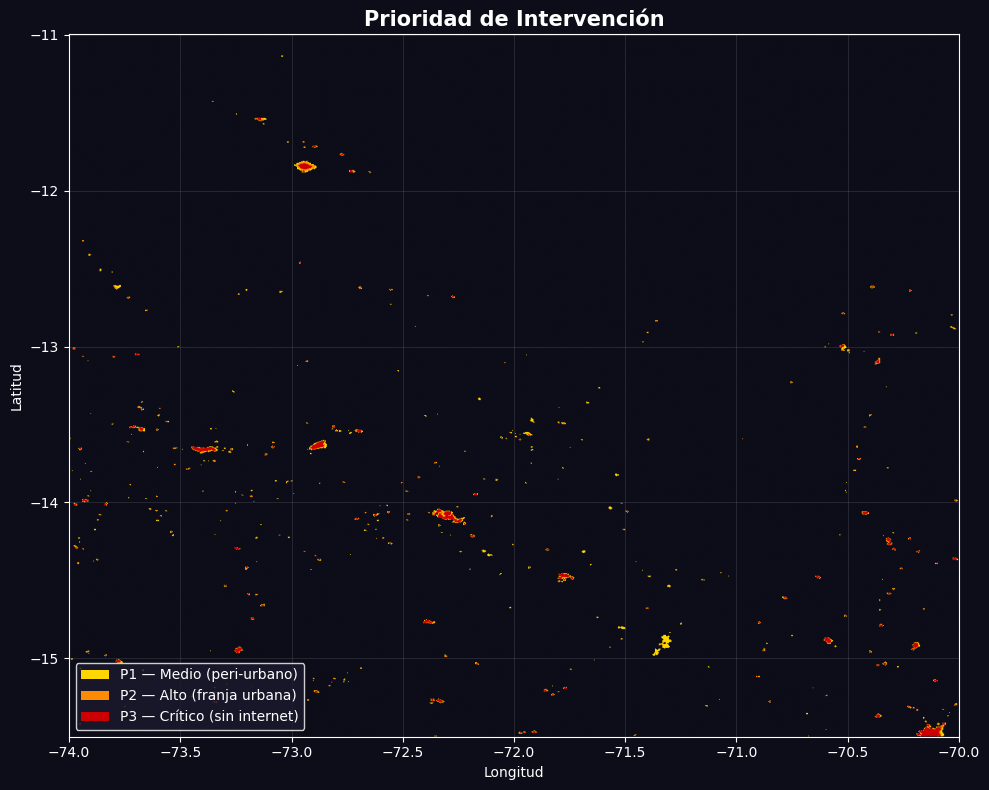

In [40]:
priority = np.zeros(vnl_norm.shape, dtype=np.uint8)

mask_p1 = (vnl_norm >= 0.10) & (conn_norm < 0.25)
mask_p2 = (vnl_norm >= 0.15) & (conn_norm < 0.15)
mask_p3 = (vnl_norm >= 0.30) & (conn_norm < 0.10)

priority[mask_p1] = 1
priority[mask_p2] = 2
priority[mask_p3] = 3

total_pixels = priority.size
print('=== Prioridad de Intervención ===')
for level, name in [(1, 'P1 — Medio   '), (2, 'P2 — Alto   '), (3, 'P3 — Crítico')]:
    count = np.sum(priority == level)
    pct   = count / total_pixels * 100
    print(f'  {name}: {count:>8,} píxeles ({pct:.2f}% del área total)')

from matplotlib.colors import BoundaryNorm
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')

colors_p = ['#0d0d1a', '#FFD700', '#FF8C00', '#CC0000']
cmap_p   = ListedColormap(colors_p)
bounds_p = [0, 1, 2, 3, 4]
norm_p   = BoundaryNorm(bounds_p, len(colors_p))

im = ax.imshow(priority, cmap=cmap_p, norm=norm_p, extent=extent,
               aspect='auto', origin='upper')
ax.set_title('Prioridad de Intervención', color='white', fontsize=15, fontweight='bold')
ax.set_xlabel('Longitud', color='white')
ax.set_ylabel('Latitud', color='white')
ax.tick_params(colors='white')
ax.grid(True, color='white', alpha=0.15, linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('white')

legend_elements = [
    mpatches.Patch(facecolor='#FFD700', label='P1 — Medio (peri-urbano)'),
    mpatches.Patch(facecolor='#FF8C00', label='P2 — Alto (franja urbana)'),
    mpatches.Patch(facecolor='#CC0000', label='P3 — Crítico (sin internet)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          facecolor='#1a1a2e', edgecolor='white',
          labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('../output/map3_priority.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Step 7 — Map 4: Social Exclusion Risk

Percentil 75 de riesgo: 1.0000
Percentil 90 de riesgo: 1.0000


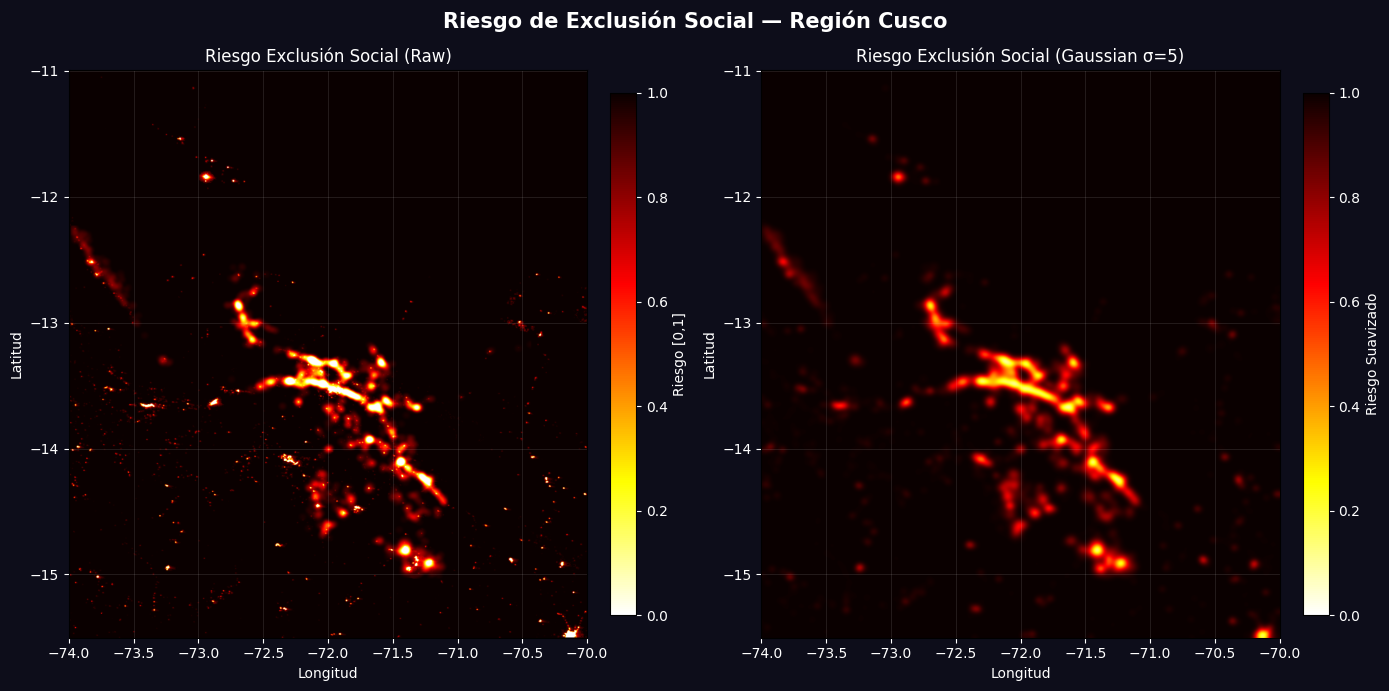

In [42]:
# Calcular riesgo de exclusión social
risk_raw = EDT * (1 - vnl_norm)

# Normalizar a [0, 1]
r_min, r_max = risk_raw.min(), risk_raw.max()
risk_norm = (risk_raw - r_min) / (r_max - r_min + 1e-10)

# Filtro gaussiano
risk_smooth = gaussian_filter(risk_norm, sigma=5)

# Percentiles
p75 = np.percentile(risk_norm, 75)
p90 = np.percentile(risk_norm, 90)
print(f'Percentil 75 de riesgo: {p75:.4f}')
print(f'Percentil 90 de riesgo: {p90:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor='#0d0d1a')
for ax in axes:
    ax.set_facecolor('#0d0d1a')

# Riesgo RAW
im1 = axes[0].imshow(risk_norm, cmap='hot_r', extent=extent,
                      vmin=0, vmax=1, aspect='auto', origin='upper')
axes[0].set_title('Riesgo Exclusión Social (Raw)', color='white', fontsize=12)
axes[0].set_xlabel('Longitud', color='white')
axes[0].set_ylabel('Latitud', color='white')
axes[0].tick_params(colors='white')
axes[0].grid(True, color='white', alpha=0.15, linewidth=0.5)
cb1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cb1.set_label('Riesgo [0,1]', color='white')
cb1.ax.yaxis.set_tick_params(color='white')
plt.setp(cb1.ax.yaxis.get_ticklabels(), color='white')

# Riesgo SUAVIZADO
im2 = axes[1].imshow(risk_smooth, cmap='hot_r', extent=extent,
                      vmin=0, vmax=risk_smooth.max(), aspect='auto', origin='upper')
axes[1].set_title('Riesgo Exclusión Social (Gaussian σ=5)', color='white', fontsize=12)
axes[1].set_xlabel('Longitud', color='white')
axes[1].set_ylabel('Latitud', color='white')
axes[1].tick_params(colors='white')
axes[1].grid(True, color='white', alpha=0.15, linewidth=0.5)
cb2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cb2.set_label('Riesgo Suavizado', color='white')
cb2.ax.yaxis.set_tick_params(color='white')
plt.setp(cb2.ax.yaxis.get_ticklabels(), color='white')

fig.suptitle('Riesgo de Exclusión Social — Región Cusco',
             color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/map4_social_risk.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Step 8 — Territorial Classification (2×2)

=== Clasificación Territorial ===
 Clase           Nombre  Píxeles  % Área  Área (km²)
     1 Urbano Conectado     2098    0.20       436.4
     2    Brecha Urbana     2856    0.27       594.0
     3  Rural Conectado    26543    2.56      5520.8
     4   Brecha Crítica  1007344   96.97    209523.5


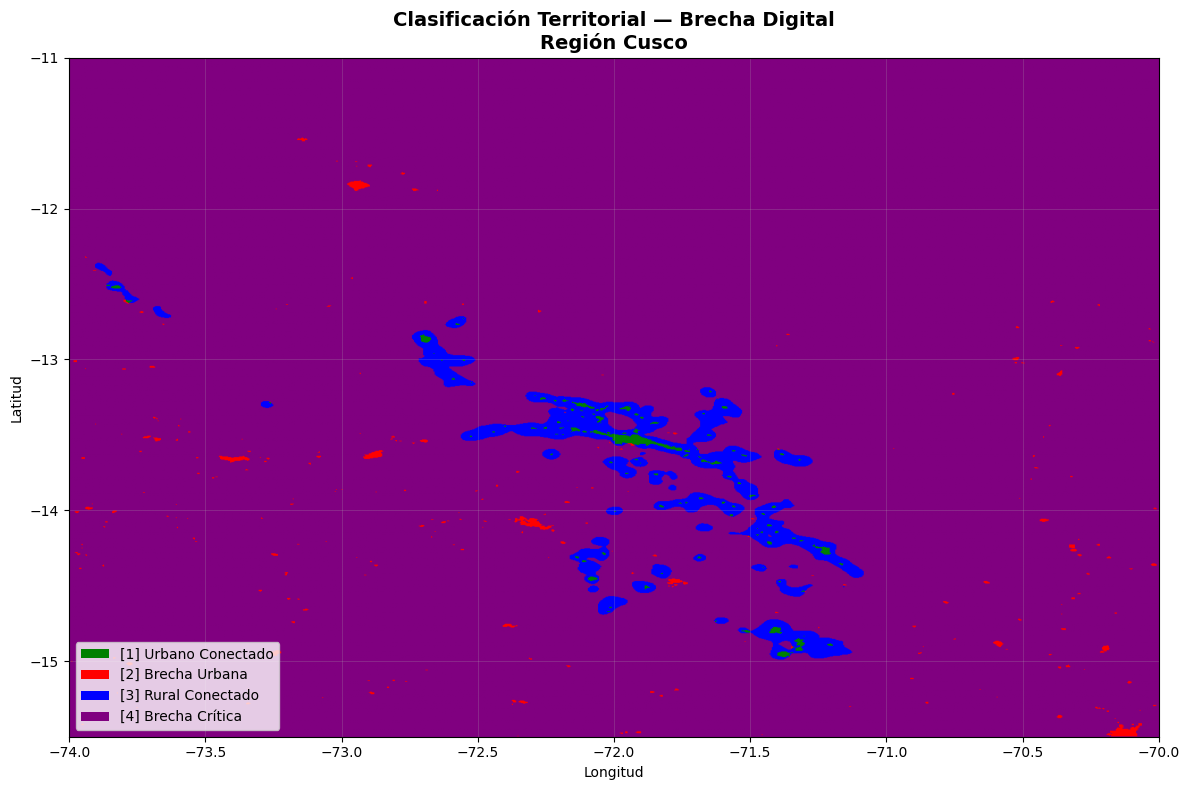


✓ Raster clasificacion_brecha.tif guardado en output/


In [45]:
THRESHOLD = 0.15

urban = vnl_norm  >= THRESHOLD
conn  = conn_norm >= THRESHOLD

classification = np.zeros(vnl_norm.shape, dtype=np.uint8)
classification[ urban &  conn] = 1  # Urbano Conectado
classification[ urban & ~conn] = 2  # Brecha Urbana
classification[~urban &  conn] = 3  # Rural Conectado
classification[~urban & ~conn] = 4  # Brecha Crítica

class_info = {
    1: ('Urbano Conectado', 'green'),
    2: ('Brecha Urbana',    'red'),
    3: ('Rural Conectado',  'blue'),
    4: ('Brecha Crítica',   'purple'),
}

# Calcular área aprox: resolución del VNL
with rasterio.open(VNL_PATH) as src:
    res_x = abs(src.res[0])  # grados
# 1 grado lat ≈ 111 km, ajustado por latitud media ~13.5°S
lat_mid = -13.5
km_per_deg_x = 111 * np.cos(np.radians(lat_mid))
km_per_deg_y = 111
pixel_area_km2 = res_x * km_per_deg_x * res_x * km_per_deg_y

total = classification.size
rows = []
for cls, (name, color) in class_info.items():
    count = int(np.sum(classification == cls))
    pct   = count / total * 100
    area  = count * pixel_area_km2
    rows.append({'Clase': cls, 'Nombre': name, 'Píxeles': count,
                 '% Área': round(pct, 2), 'Área (km²)': round(area, 1)})

df_class = pd.DataFrame(rows)
print('=== Clasificación Territorial ===')
print(df_class.to_string(index=False))

# Mapa de clasificación
colors_cls = ['#111111', 'green', 'red', 'blue', 'purple']
cmap_cls   = ListedColormap(colors_cls)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(classification, cmap=cmap_cls, extent=extent,
               vmin=0, vmax=4, aspect='auto', origin='upper')
ax.set_title('Clasificación Territorial — Brecha Digital\nRegión Cusco',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.grid(True, alpha=0.3, linewidth=0.5)

legend_elements = [
    mpatches.Patch(facecolor='green',  label='[1] Urbano Conectado'),
    mpatches.Patch(facecolor='red',    label='[2] Brecha Urbana'),
    mpatches.Patch(facecolor='blue',   label='[3] Rural Conectado'),
    mpatches.Patch(facecolor='purple', label='[4] Brecha Crítica'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig('../output/map5_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar raster de clasificación
with rasterio.open(VNL_PATH) as src:
    profile = src.profile.copy()

profile.update(dtype='uint8', count=1, nodata=0)
with rasterio.open('../output/clasificacion_brecha.tif', 'w', **profile) as dst:
    dst.write(classification, 1)

print('\n✓ Raster clasificacion_brecha.tif guardado en output/')

---
## Step 9 — Statistical Summary

In [46]:
# Submuestra cada 40 píxeles para análisis estadístico
step = 40
vnl_flat  = vnl_norm[::step, ::step].ravel()
conn_flat = conn_norm[::step, ::step].ravel()
ibd_flat  = IBD[::step, ::step].ravel()
cls_flat  = classification[::step, ::step].ravel()

df_stats = pd.DataFrame({
    'VNL':          vnl_flat,
    'Conectividad': conn_flat,
    'IBD':          ibd_flat,
    'Clase':        cls_flat
})
df_stats = df_stats[df_stats['Clase'] > 0]  # excluir clase 0

# Mapa de nombres de clase
df_stats['Clase_nombre'] = df_stats['Clase'].map({
    1: 'Urbano Conectado',
    2: 'Brecha Urbana',
    3: 'Rural Conectado',
    4: 'Brecha Crítica'
})

# Estadísticas descriptivas por clase
print('=== Estadísticas Descriptivas por Clase ===')
summary = df_stats.groupby('Clase_nombre')[['VNL', 'Conectividad', 'IBD']].agg(
    ['mean', 'std', 'min', 'max']
).round(4)
print(summary.to_string())

# Correlación de Pearson VNL vs Conectividad
r, p = stats.pearsonr(df_stats['VNL'], df_stats['Conectividad'])
print(f'\n=== Correlación de Pearson (VNL vs Conectividad) ===')
print(f'  r = {r:.4f} | p-value = {p:.4e}')
if p < 0.05:
    print(f'  → Correlación estadísticamente significativa (p < 0.05)')
else:
    print(f'  → No significativa (p ≥ 0.05)')

=== Estadísticas Descriptivas por Clase ===
                     VNL                        Conectividad                            IBD                        
                    mean     std    min     max         mean    std     min     max    mean     std     min     max
Clase_nombre                                                                                                       
Brecha Crítica    0.0008  0.0070  0.000  0.1214       0.0031  0.016  0.0000  0.1401 -0.0023  0.0172 -0.1401  0.1214
Rural Conectado   0.0141  0.0301  0.000  0.1326       0.4153  0.253  0.1616  0.9999 -0.4012  0.2344 -0.9036 -0.1557
Urbano Conectado  0.8750     NaN  0.875  0.8750       0.8869    NaN  0.8869  0.8869 -0.0119     NaN -0.0119 -0.0119

=== Correlación de Pearson (VNL vs Conectividad) ===
  r = 0.4578 | p-value = 1.4678e-37
  → Correlación estadísticamente significativa (p < 0.05)


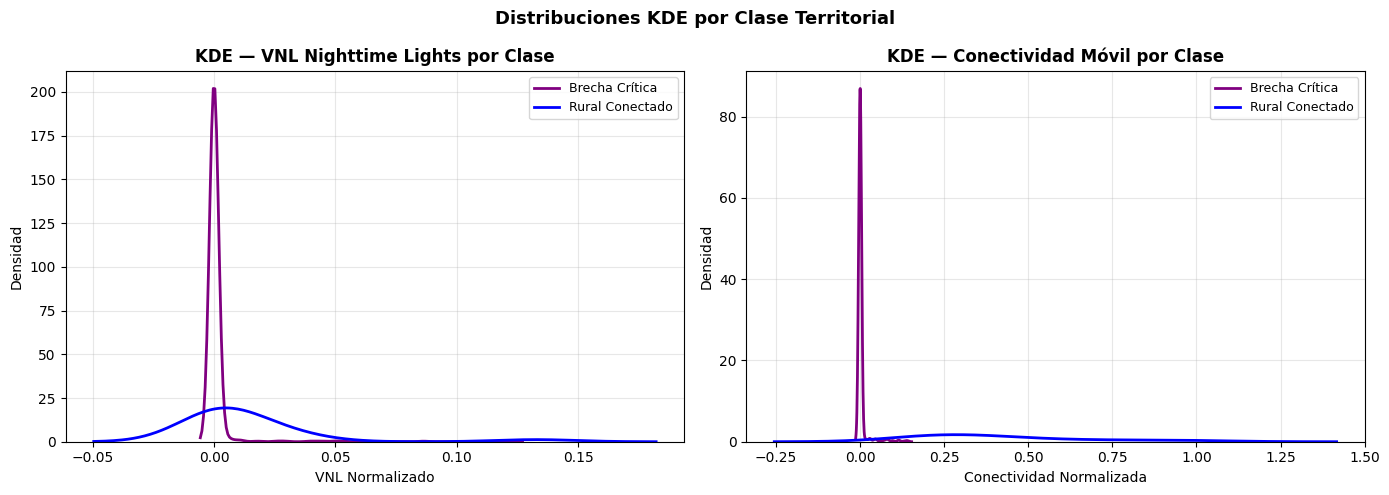

In [48]:
# KDE Plots por clase
palette = {
    'Urbano Conectado': 'green',
    'Brecha Urbana':    'red',
    'Rural Conectado':  'blue',
    'Brecha Crítica':   'purple'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls_name, grp in df_stats.groupby('Clase_nombre'):
    color = palette.get(cls_name, 'gray')
    sns.kdeplot(grp['VNL'], ax=axes[0], label=cls_name, color=color, linewidth=2)
    sns.kdeplot(grp['Conectividad'], ax=axes[1], label=cls_name, color=color, linewidth=2)

axes[0].set_title('KDE — VNL Nighttime Lights por Clase', fontweight='bold')
axes[0].set_xlabel('VNL Normalizado')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('KDE — Conectividad Móvil por Clase', fontweight='bold')
axes[1].set_xlabel('Conectividad Normalizada')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Distribuciones KDE por Clase Territorial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/kde_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Cambiar step de 40 a 10 para capturar más píxeles de clases minoritarias
step = 10
vnl_flat  = vnl_norm[::step, ::step].ravel()
conn_flat = conn_norm[::step, ::step].ravel()
ibd_flat  = IBD[::step, ::step].ravel()
cls_flat  = classification[::step, ::step].ravel()

df_stats = pd.DataFrame({
    'VNL':          vnl_flat,
    'Conectividad': conn_flat,
    'IBD':          ibd_flat,
    'Clase':        cls_flat
})
df_stats = df_stats[df_stats['Clase'] > 0]

df_stats['Clase_nombre'] = df_stats['Clase'].map({
    1: 'Urbano Conectado',
    2: 'Brecha Urbana',
    3: 'Rural Conectado',
    4: 'Brecha Crítica'
})

cls1_vnl = df_stats[df_stats['Clase'] == 1]['VNL'].values
cls4_vnl = df_stats[df_stats['Clase'] == 4]['VNL'].values

print(f'n Clase 1: {len(cls1_vnl)}')
print(f'n Clase 4: {len(cls4_vnl)}')

t_stat, p_val = stats.ttest_ind(cls1_vnl, cls4_vnl, equal_var=False)

pooled_std = np.sqrt((cls1_vnl.std()**2 + cls4_vnl.std()**2) / 2)
cohens_d   = (cls1_vnl.mean() - cls4_vnl.mean()) / (pooled_std + 1e-10)

print(f'\n=== Welch t-test: Clase 1 vs Clase 4 (VNL) ===')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val:.4e}')
print(f'  Cohen\'s d   : {cohens_d:.4f}')

if abs(cohens_d) > 0.8:
    print('  → Efecto GRANDE (|d| > 0.8): diferencia sustancial entre clases.')
elif abs(cohens_d) > 0.5:
    print('  → Efecto MEDIO (0.5 < |d| ≤ 0.8)')
else:
    print('  → Efecto PEQUEÑO (|d| ≤ 0.5)')

n Clase 1: 19
n Clase 4: 10277

=== Welch t-test: Clase 1 vs Clase 4 (VNL) ===
  t-statistic : 6.1566
  p-value     : 8.1904e-06
  Cohen's d   : 2.0519
  → Efecto GRANDE (|d| > 0.8): diferencia sustancial entre clases.


---
## Step 10 — Export Deliverables

=== Exportando rasters GeoTIFF ===
  ✓ Guardado: ../output/vnl_norm.tif
  ✓ Guardado: ../output/conn_norm.tif
  ✓ Guardado: ../output/ibd_brecha_digital.tif
  ✓ output/clasificacion_brecha.tif (guardado en Step 8)

=== Generando Dashboard Final ===


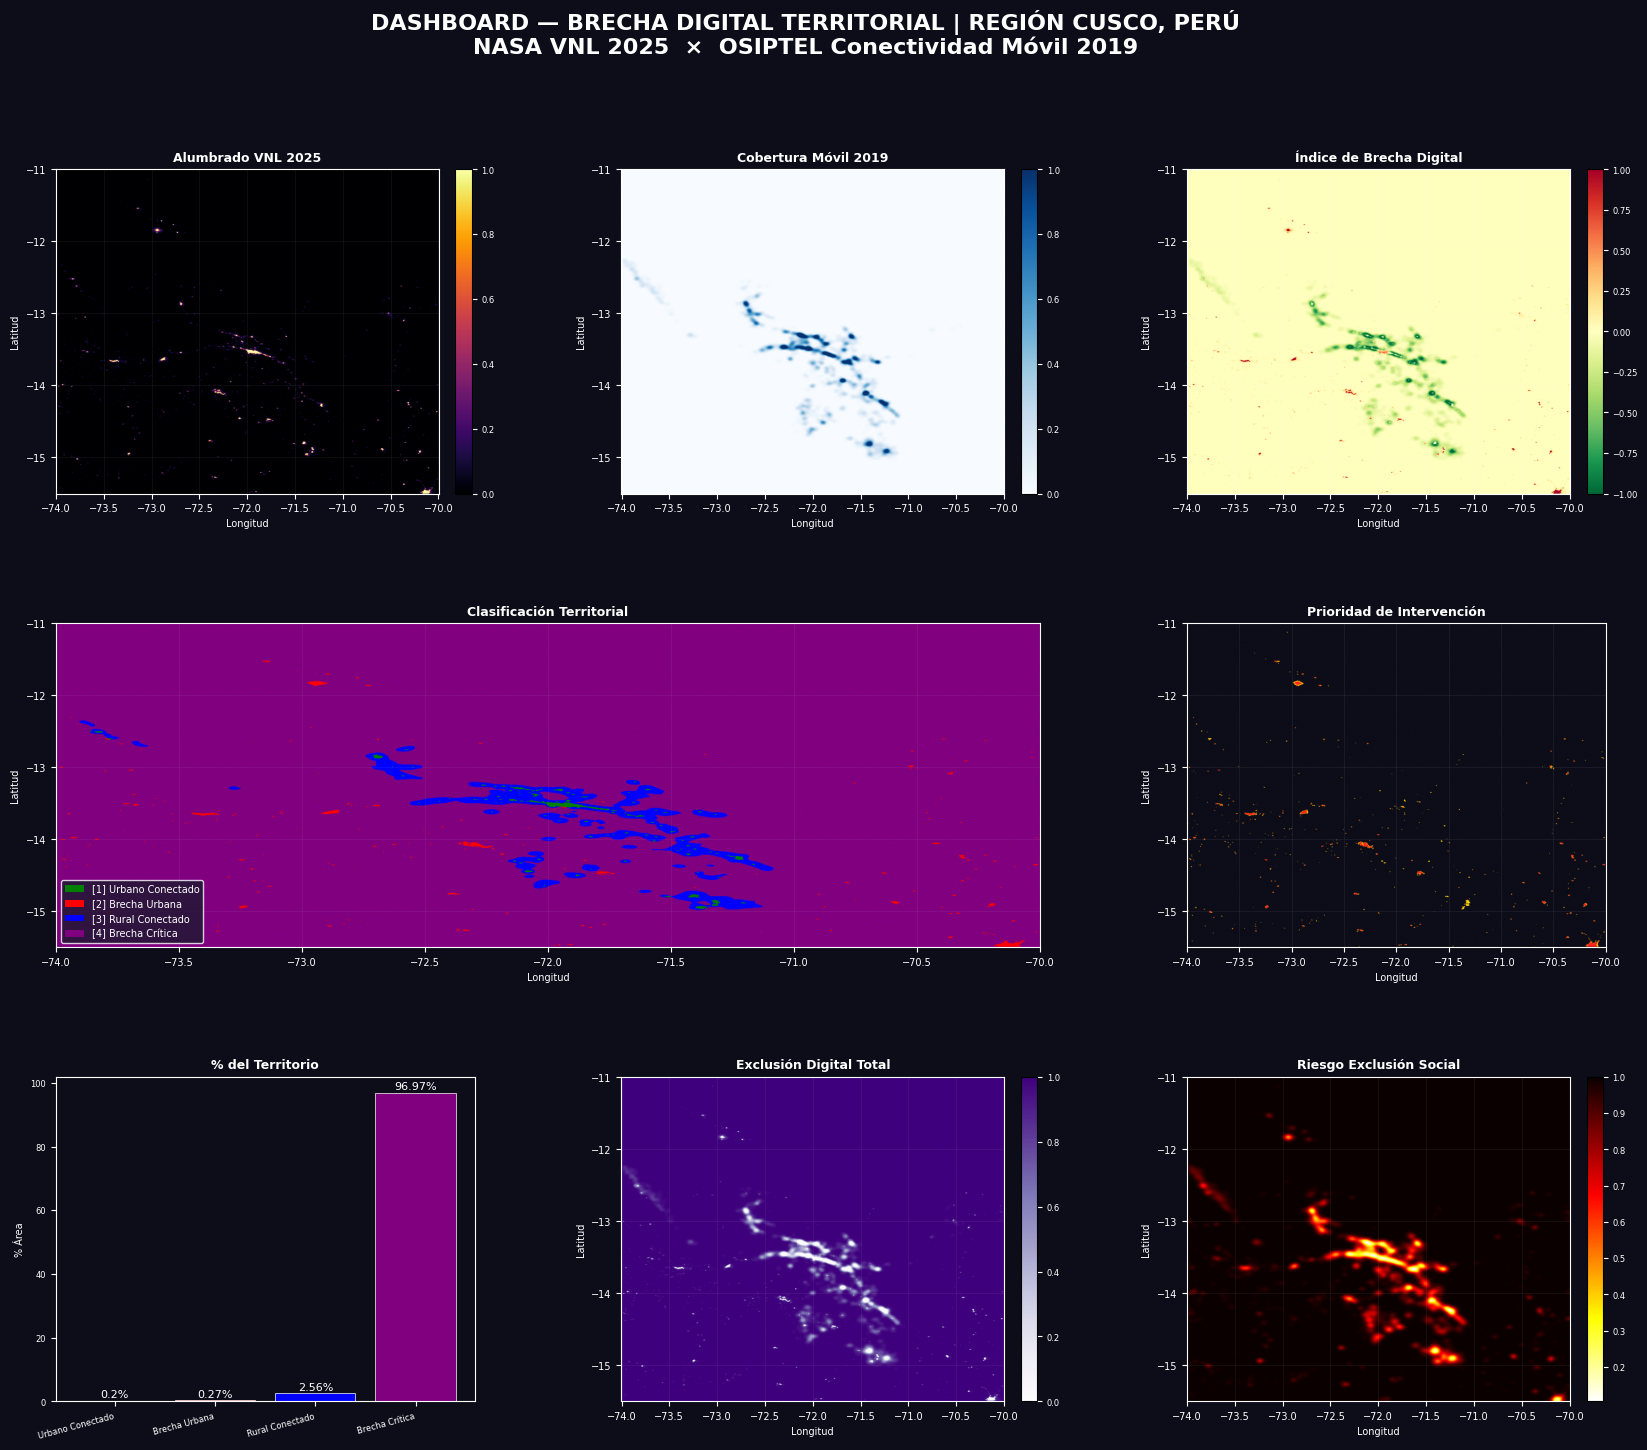


✓ Dashboard guardado: output/dashboard_brecha_digital.png

=== ¡Pipeline completado exitosamente! ===
Archivos en output/:
  clasificacion_brecha.tif                 50.1 KB
  conn_norm.tif                            542.9 KB
  dashboard_brecha_digital.png             1040.2 KB
  ibd_brecha_digital.tif                   717.0 KB
  kde_plots.png                            75.5 KB
  map1_vnl_nighttime.png                   384.3 KB
  map2_ibd_edt.png                         740.6 KB
  map3_priority.png                        305.6 KB
  map4_social_risk.png                     308.5 KB
  map5_classification.png                  325.6 KB
  vnl_norm.tif                             319.8 KB


In [54]:
def save_raster(array, filename, profile, dtype='float32'):
    """Guarda un array como GeoTIFF alineado al grid VNL."""
    p = profile.copy()
    p.update(dtype=dtype, count=1, nodata=None)
    with rasterio.open(filename, 'w', **p) as dst:
        dst.write(array.astype(dtype), 1)
    print(f'  ✓ Guardado: {filename}')

with rasterio.open(VNL_PATH) as src:
    base_profile = src.profile.copy()

print('=== Exportando rasters GeoTIFF ===')
save_raster(vnl_norm,       '../output/vnl_norm.tif',              base_profile)
save_raster(conn_norm,      '../output/conn_norm.tif',             base_profile)
save_raster(IBD,            '../output/ibd_brecha_digital.tif',    base_profile)
# clasificacion_brecha.tif ya fue guardado en Step 8
print('  ✓ output/clasificacion_brecha.tif (guardado en Step 8)')

print('\n=== Generando Dashboard Final ===')

fig = plt.figure(figsize=(20, 16), facecolor='#0d0d1a')
fig.suptitle(
    'DASHBOARD — BRECHA DIGITAL TERRITORIAL | REGIÓN CUSCO, PERÚ\n'
    'NASA VNL 2025  ×  OSIPTEL Conectividad Móvil 2019',
    color='white', fontsize=16, fontweight='bold', y=0.98
)

gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

def dark_ax(ax):
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='white', labelsize=7)
    ax.set_xlabel('Longitud', color='white', fontsize=7)
    ax.set_ylabel('Latitud',  color='white', fontsize=7)
    ax.grid(True, color='white', alpha=0.1, linewidth=0.4)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# [0,0] VNL normalizado
ax1 = fig.add_subplot(gs[0, 0])
dark_ax(ax1)
im = ax1.imshow(vnl_norm, cmap='inferno', extent=extent, vmin=0, vmax=1, aspect='auto', origin='upper')
ax1.set_title('Alumbrado VNL 2025', color='white', fontsize=9, fontweight='bold')
cb = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors='white', labelsize=6)

# [0,1] Conectividad normalizada
ax2 = fig.add_subplot(gs[0, 1])
dark_ax(ax2)
im = ax2.imshow(conn_norm, cmap='Blues', extent=extent, vmin=0, vmax=1, aspect='auto', origin='upper')
ax2.set_title('Cobertura Móvil 2019', color='white', fontsize=9, fontweight='bold')
cb = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors='white', labelsize=6)

# [0,2] IBD
ax3 = fig.add_subplot(gs[0, 2])
dark_ax(ax3)
im = ax3.imshow(IBD, cmap='RdYlGn_r', extent=extent, vmin=-1, vmax=1, aspect='auto', origin='upper')
ax3.set_title('Índice de Brecha Digital', color='white', fontsize=9, fontweight='bold')
cb = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors='white', labelsize=6)

# [1,0:2] Clasificación (ocupa 2 columnas)
ax4 = fig.add_subplot(gs[1, 0:2])
dark_ax(ax4)
colors_cls2 = ['#111111', 'green', 'red', 'blue', 'purple']
cmap_cls2   = ListedColormap(colors_cls2)
im = ax4.imshow(classification, cmap=cmap_cls2, extent=extent, vmin=0, vmax=4, aspect='auto', origin='upper')
ax4.set_title('Clasificación Territorial', color='white', fontsize=9, fontweight='bold')
legend_elements2 = [
    mpatches.Patch(facecolor='green',  label='[1] Urbano Conectado'),
    mpatches.Patch(facecolor='red',    label='[2] Brecha Urbana'),
    mpatches.Patch(facecolor='blue',   label='[3] Rural Conectado'),
    mpatches.Patch(facecolor='purple', label='[4] Brecha Crítica'),
]
ax4.legend(handles=legend_elements2, loc='lower left', facecolor='#1a1a2e',
           edgecolor='white', labelcolor='white', fontsize=7)

# [1,2] Prioridad
ax5 = fig.add_subplot(gs[1, 2])
dark_ax(ax5)
colors_p2 = ['#0d0d1a', '#FFD700', '#FF8C00', '#FF2020']
cmap_p2   = ListedColormap(colors_p2)
im = ax5.imshow(priority, cmap=cmap_p2, extent=extent, vmin=0, vmax=3, aspect='auto', origin='upper')
ax5.set_title('Prioridad de Intervención', color='white', fontsize=9, fontweight='bold')

# [2,0] Barplot % territorio
ax6 = fig.add_subplot(gs[2, 0])
ax6.set_facecolor('#0d0d1a')
names  = [r['Nombre'] for r in rows]
pcts   = [r['% Área'] for r in rows]
colors_bar = ['green', 'red', 'blue', 'purple']
bars = ax6.bar(names, pcts, color=colors_bar, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, pcts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct}%', ha='center', va='bottom', color='white', fontsize=8)
ax6.set_title('% del Territorio', color='white', fontsize=9, fontweight='bold')
ax6.set_ylabel('% Área', color='white', fontsize=7)
ax6.tick_params(colors='white', labelsize=6)
ax6.set_facecolor('#0d0d1a')
for spine in ax6.spines.values():
    spine.set_edgecolor('white')
ax6.set_xticklabels(names, rotation=15, ha='right', fontsize=6, color='white')

# [2,1] EDT
ax7 = fig.add_subplot(gs[2, 1])
dark_ax(ax7)
im = ax7.imshow(EDT, cmap='Purples', extent=extent, vmin=0, vmax=1, aspect='auto', origin='upper')
ax7.set_title('Exclusión Digital Total', color='white', fontsize=9, fontweight='bold')
cb = plt.colorbar(im, ax=ax7, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors='white', labelsize=6)

# [2,2] Riesgo social suavizado
ax8 = fig.add_subplot(gs[2, 2])
dark_ax(ax8)
im = ax8.imshow(risk_smooth, cmap='hot_r', extent=extent, aspect='auto', origin='upper')
ax8.set_title('Riesgo Exclusión Social', color='white', fontsize=9, fontweight='bold')
cb = plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors='white', labelsize=6)

plt.savefig('../output/dashboard_brecha_digital.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('\n✓ Dashboard guardado: output/dashboard_brecha_digital.png')
print('\n=== ¡Pipeline completado exitosamente! ===')
print('Archivos en output/:')
for f in sorted(os.listdir('../output/')):
    size = os.path.getsize(f'../output/{f}') / 1024
    print(f'  {f:<40} {size:.1f} KB')